In [1]:
from google.colab import files
uploaded = files.upload()

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured")

!rm -f /content/*.zip
!kaggle datasets download -d shoybhasan/camus-human-heart-data -p /content --force

!rm -rf /content/camus_data
!mkdir -p /content/camus_data
!unzip -q /content/camus-human-heart-data.zip -d /content/camus_data

!rm -rf /content/camus_full
!mkdir -p /content/camus_full
!unzip -q /content/camus_data/download -d /content/camus_full

import os

print(os.listdir("/content/camus_full")[:10])

root_dir = "/content/camus_full/database_nifti"

print("Using dataset root:", root_dir)
print("Patient folders:", len(os.listdir(root_dir)))
print(os.listdir(root_dir)[:5])

Saving kaggle.json to kaggle.json
Kaggle API configured
Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
 96% 3.36G/3.50G [00:01<00:00, 1.54GB/s]
100% 3.50G/3.50G [00:02<00:00, 1.78GB/s]
['database_nifti']
Using dataset root: /content/camus_full/database_nifti
Patient folders: 500
['patient0212', 'patient0388', 'patient0458', 'patient0482', 'patient0139']


In [2]:
# =========================
# DATASET ROOT
# =========================
POSSIBLE_ROOTS = [
    "/content/camus_full/database_nifti",
    "/mnt/data/camus_full/database_nifti",
]

root_dir = None
for p in POSSIBLE_ROOTS:
    if os.path.exists(p):
        root_dir = p
        break

if root_dir is None:
    raise FileNotFoundError("CAMUS dataset root not found. Update POSSIBLE_ROOTS or set root_dir manually.")

print("Using dataset root:", root_dir)
print("Number of patient folders:", len(os.listdir(root_dir)))

Using dataset root: /content/camus_full/database_nifti
Number of patient folders: 500


In [3]:
# =========================
# CAMUS DATASET SUMMARY
# =========================

import os

patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

num_patients = len(patients)

total_images = 0
total_masks = 0

for patient in patients:
    p_dir = os.path.join(root_dir, patient)
    files = os.listdir(p_dir)

    images = [f for f in files if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz")]
    masks  = [f for f in files if f.endswith("_gt.nii.gz")]

    total_images += len(images)
    total_masks += len(masks)

print("=========== CAMUS DATASET SUMMARY ===========")
print("Total patients:", num_patients)
print("Total image volumes:", total_images)
print("Total mask volumes:", total_masks)
print("=============================================")

print("\nExample patient folder:", patients[0])
print("Files inside example patient folder:")
print(os.listdir(os.path.join(root_dir, patients[0])))

=========== CAMUS DATASET SUMMARY ===========
Total patients: 500
Total image volumes: 3000
Total mask volumes: 3000

Example patient folder: patient0001
Files inside example patient folder:
['Info_2CH.cfg', 'MANDATORY_CITATION.md', 'patient0001_2CH_ED.nii.gz', 'patient0001_2CH_ES.nii.gz', 'patient0001_4CH_half_sequence_gt.nii.gz', 'patient0001_4CH_ED.nii.gz', 'patient0001_4CH_half_sequence.nii.gz', 'patient0001_2CH_half_sequence.nii.gz', 'Info_4CH.cfg', 'patient0001_2CH_ES_gt.nii.gz', 'patient0001_4CH_ED_gt.nii.gz', 'patient0001_2CH_half_sequence_gt.nii.gz', 'patient0001_4CH_ES_gt.nii.gz', 'patient0001_2CH_ED_gt.nii.gz', 'patient0001_4CH_ES.nii.gz']


In [4]:
# =========================
# IMPORTS
# =========================
import os
import gc
import cv2
import time
import copy
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

!pip install -q segmentation-models-pytorch
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00


In [5]:
# =========================
# SEED / DEVICE / SETTINGS
# =========================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10
NUM_CLASSES = 4

NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

Device: cuda


In [6]:
# =========================
# TRANSFORMS
# =========================
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [7]:
# =========================
# PATIENT-LEVEL SPLIT
# =========================
all_patients = sorted([
    p for p in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, p))
])

rng = np.random.RandomState(SEED)
rng.shuffle(all_patients)

split_idx = int(0.8 * len(all_patients))
train_patients = all_patients[:split_idx]
val_patients = all_patients[split_idx:]

print("Train patients:", len(train_patients))
print("Val patients:", len(val_patients))

Train patients: 400
Val patients: 100


In [8]:
def collect_pairs(patient_list, root_dir):
    pairs = []

    for patient in patient_list:
        patient_dir = os.path.join(root_dir, patient)
        files_here = os.listdir(patient_dir)

        for f in files_here:
            if f.endswith(".nii.gz") and not f.endswith("_gt.nii.gz"):
                if ("_ED.nii.gz" in f) or ("_ES.nii.gz" in f):
                    img_path = os.path.join(patient_dir, f)
                    mask_path = os.path.join(patient_dir, f.replace(".nii.gz", "_gt.nii.gz"))

                    if os.path.exists(mask_path):
                        pairs.append((img_path, mask_path))

    return pairs

In [9]:
# =========================
# DATASET
# =========================
class CamusNiftiDataset(Dataset):
    def __init__(self, pairs, transform=None, size=256):
        self.pairs = pairs
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = np.asanyarray(nib.load(img_path).dataobj).astype(np.float32)
        mask = np.asanyarray(nib.load(mask_path).dataobj).astype(np.int64)

        if img.ndim == 3:
            img = img[:, :, 0]
        if mask.ndim == 3:
            mask = mask[:, :, 0]

        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"].float()
            mask = aug["mask"].long()
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask

In [10]:
train_pairs = collect_pairs(train_patients, root_dir)
val_pairs = collect_pairs(val_patients, root_dir)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

Train samples: 1600
Val samples: 400


In [11]:
train_ds = CamusNiftiDataset(train_pairs, transform=train_transform, size=IMAGE_SIZE)
val_ds   = CamusNiftiDataset(val_pairs, transform=val_transform, size=IMAGE_SIZE)

print("Train dataset:", len(train_ds))
print("Val dataset:", len(val_ds))

Train dataset: 1600
Val dataset: 400


In [12]:
img, mask = train_ds[0]

print(img.shape)
print(mask.shape)
print(mask.dtype)
print(torch.unique(mask))

torch.Size([1, 256, 256])
torch.Size([256, 256])
torch.int64
tensor([0, 1, 2, 3])


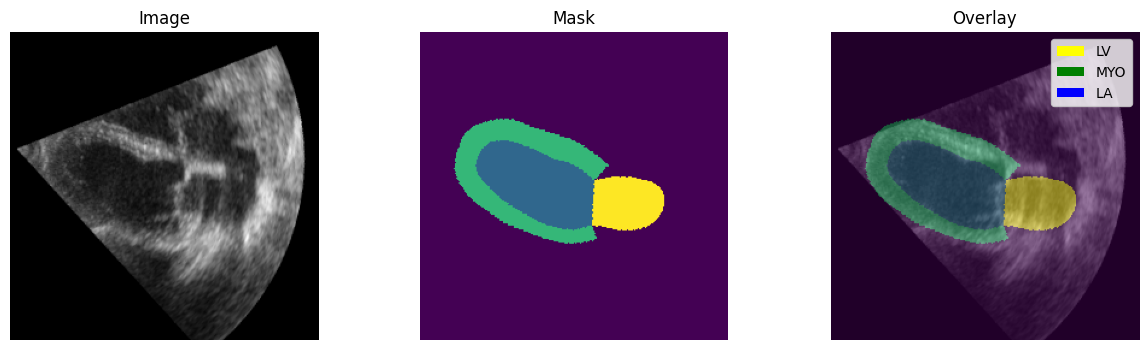

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

img, mask = train_ds[0]

img_np = img.squeeze().cpu().numpy()
mask_np = mask.cpu().numpy()

colors = [
    (0,0,0,0),        # BG transparent
    (1,0,0,0.6),      # LV yellow
    (0,1,0,0.6),      # MYO green
    (0,0,1,0.6)       # LA blue
]

legend_elements = [
    Patch(facecolor='yellow', label='LV'),
    Patch(facecolor='green', label='MYO'),
    Patch(facecolor='blue', label='LA')
]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img_np, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask_np)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img_np, cmap="gray")
plt.imshow(mask_np, alpha=0.5)
plt.legend(handles=legend_elements, loc="upper right")
plt.axis("off")

plt.show()

In [18]:
# =========================
# SAMPLERS
# WEIGHTED + BALANCED
# =========================
def get_mask_class_presence(mask_path):
    mask = np.asanyarray(nib.load(mask_path).dataobj).astype(np.int64)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    return np.unique(mask)

def compute_weighted_sampler_weights(dataset):
    weights = []
    for _, mask_path in dataset.pairs:
        classes_present = get_mask_class_presence(mask_path)

        w = 1.0
        if 3 in classes_present:   # LA
            w += 2.0
        if 2 in classes_present:   # MYO
            w += 1.5
        if 1 in classes_present:   # LV
            w += 1.0

        weights.append(w)

    return torch.DoubleTensor(weights)

def compute_balanced_sampler_weights(dataset):
    weights = []
    for _, mask_path in dataset.pairs:
        classes_present = get_mask_class_presence(mask_path)

        if 3 in classes_present:
            w = 4.0
        elif 2 in classes_present:
            w = 3.0
        elif 1 in classes_present:
            w = 2.0
        else:
            w = 1.0

        weights.append(w)

    return torch.DoubleTensor(weights)

def make_train_loader(train_ds, sampler_choice):
    if sampler_choice == "weighted":
        sample_weights = compute_weighted_sampler_weights(train_ds)
    elif sampler_choice == "balanced":
        sample_weights = compute_balanced_sampler_weights(train_ds)
    else:
        raise ValueError("sampler_choice must be 'weighted' or 'balanced'")

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    return DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        worker_init_fn=seed_worker,
        generator=g,
    )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
)

SAMPLER_CHOICE = "balanced"
train_loader = make_train_loader(train_ds, SAMPLER_CHOICE)

print("Training sampler:", SAMPLER_CHOICE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Training sampler: balanced
Train batches: 400
Val batches: 100


In [19]:
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Batch size:", BATCH_SIZE)

Train samples: 1600
Val samples: 400
Train batches: 400
Val batches: 100
Batch size: 4


In [20]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=g,
)

SAMPLER_CHOICE = "balanced"   # only for preview / analysis
train_loader = make_train_loader(train_ds, SAMPLER_CHOICE)

print("Training sampler:", SAMPLER_CHOICE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Training sampler: balanced
Train batches: 400
Val batches: 100


In [21]:
# =========================
# PIXEL SHARE CHECK
# =========================
def compute_pixel_share(loader, max_batches=None):
    cnt = Counter()

    for b, (_, y) in enumerate(loader):
        y = y.numpy()
        for cls in [0, 1, 2, 3]:
            cnt[cls] += int((y == cls).sum())

        if max_batches is not None and (b + 1) >= max_batches:
            break

    total = sum(cnt.values())
    return {
        "BG": cnt[0] / total,
        "LV": cnt[1] / total,
        "MYO": cnt[2] / total,
        "LA": cnt[3] / total
    }

pixel_share = compute_pixel_share(train_loader, max_batches=20)
pd.DataFrame([pixel_share])

,BG,LV,MYO,LA
0,0.757335,0.092069,0.10117,0.049426


In [22]:
# =========================
# MODELS
# =========================
def model_unet():     # Paper 1 + Paper 5
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_deeplab():  # Paper 2
    return smp.DeepLabV3(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

def model_resunet():  # Paper 4
    return smp.Unet(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=1,
        classes=NUM_CLASSES
    ).to(device)

In [23]:
# =========================
# LOSSES
# NON-FOCAL = WEIGHTED CE
# FOCAL + DICE = FOR ALL FOCAL RUNS
# =========================
def soft_dice_loss(logits, targets, num_classes=NUM_CLASSES, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_oh = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = torch.sum(probs * targets_oh, dims)
    union = torch.sum(probs + targets_oh, dims)
    dice = (2 * intersection + eps) / (union + eps)

    # ignore background
    return 1 - dice[1:].mean()

class CEPlusDice(nn.Module):
    def __init__(self, ce_weight=0.5, ce_loss=None):
        super().__init__()
        self.ce_weight = ce_weight
        self.ce = ce_loss if ce_loss is not None else nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + (1 - self.ce_weight) * soft_dice_loss(logits, targets)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_map = self.alpha[targets]
            focal = alpha_map * focal

        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        return focal

class FocalPlusDice(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, focal_weight=0.5):
        super().__init__()
        self.focal = FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        return self.focal_weight * self.focal(logits, targets) + (1 - self.focal_weight) * soft_dice_loss(logits, targets)

class_weights = torch.tensor([0.2, 1.0, 1.0, 1.3], device=device)

ce_weighted = nn.CrossEntropyLoss(weight=class_weights)
ce_plus_dice = CEPlusDice(ce_weight=0.5, ce_loss=ce_weighted)

focal_plus_dice = FocalPlusDice(
    alpha=class_weights,
    gamma=2.0,
    focal_weight=0.5
)

print("Losses ready")
print("Class weights:", class_weights.detach().cpu().numpy())

Losses ready
Class weights: [0.2 1.  1.  1.3]


In [24]:
# =========================
# METRICS
# =========================
def dice_per_class(preds, targets, cls, eps=1e-6):
    pred_c = (preds == cls).astype(np.uint8)
    targ_c = (targets == cls).astype(np.uint8)

    inter = (pred_c * targ_c).sum()
    denom = pred_c.sum() + targ_c.sum()

    if denom == 0:
        return np.nan

    return (2.0 * inter + eps) / (denom + eps)

def evaluate_fast(model, loader):
    model.eval()

    d1, d2, d3 = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_np = y.numpy()

            for i in range(len(preds)):
                d_lv  = dice_per_class(preds[i], y_np[i], 1)
                d_myo = dice_per_class(preds[i], y_np[i], 2)
                d_la  = dice_per_class(preds[i], y_np[i], 3)

                if not np.isnan(d_lv):
                    d1.append(d_lv)
                if not np.isnan(d_myo):
                    d2.append(d_myo)
                if not np.isnan(d_la):
                    d3.append(d_la)

    fg_all = d1 + d2 + d3
    return {
        "dice_LV":  float(np.mean(d1)) if len(d1) else np.nan,
        "dice_MYO": float(np.mean(d2)) if len(d2) else np.nan,
        "dice_LA":  float(np.mean(d3)) if len(d3) else np.nan,
        "fg_dice_mean": float(np.mean(fg_all)) if len(fg_all) else np.nan
    }

In [25]:
# =========================
# OPTIONAL HD95
# =========================
try:
    !pip install -q medpy
    from medpy.metric.binary import hd95 as medpy_hd95
    HD95_AVAILABLE = True
except:
    HD95_AVAILABLE = False

def evaluate_hd95_only(model, loader):
    if not HD95_AVAILABLE:
        return {
            "hd95_LV": np.nan,
            "hd95_MYO": np.nan,
            "hd95_LA": np.nan
        }

    model.eval()
    hd_lv, hd_myo, hd_la = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_np = y.numpy()

            for i in range(len(preds)):
                for cls, bucket in [(1, hd_lv), (2, hd_myo), (3, hd_la)]:
                    pred_bin = (preds[i] == cls).astype(np.uint8)
                    true_bin = (y_np[i] == cls).astype(np.uint8)

                    if pred_bin.sum() == 0 or true_bin.sum() == 0:
                        continue

                    try:
                        bucket.append(medpy_hd95(pred_bin, true_bin))
                    except:
                        pass

    return {
        "hd95_LV":  float(np.mean(hd_lv))  if len(hd_lv)  else np.nan,
        "hd95_MYO": float(np.mean(hd_myo)) if len(hd_myo) else np.nan,
        "hd95_LA":  float(np.mean(hd_la))  if len(hd_la)  else np.nan
    }

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 56.7 MB/s eta 0:00:00


In [26]:
# =========================
# TRAINING
# =========================
train_histories = {}

def train_model_best(model, loss_fn, epochs=10, log_every=10, patience=3, lr=1e-4, run_name="run"):
    global train_loader, val_loader

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=1
    )
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_score = -1
    best_wts = None
    wait = 0
    history = []

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0

        for bi, (x, y) in enumerate(train_loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).long()

            opt.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = loss_fn(logits, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            train_loss_sum += loss.item()

        train_loss = train_loss_sum / max(1, len(train_loader))

        model.eval()
        val_loss_sum = 0.0
        val_dices = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True).long()

                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = loss_fn(logits, y)

                val_loss_sum += loss.item()

                preds = torch.argmax(logits, dim=1).cpu().numpy()
                y_np = y.cpu().numpy()

                batch_fg = []
                for i in range(len(preds)):
                    for cls in [1, 2, 3]:
                        d = dice_per_class(preds[i], y_np[i], cls)
                        if not np.isnan(d):
                            batch_fg.append(d)

                if len(batch_fg):
                    val_dices.append(np.mean(batch_fg))

        val_loss = val_loss_sum / max(1, len(val_loader))
        val_score = float(np.mean(val_dices)) if len(val_dices) else 0.0

        scheduler.step(val_score)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_fg_dice": val_score,
            "lr": opt.param_groups[0]["lr"]
        })

        print(f"{run_name} | Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_fg_dice={val_score:.4f}")

        if val_score > best_score:
            best_score = val_score
            best_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered for {run_name}")
                break

    if best_wts is not None:
        model.load_state_dict(best_wts)

    train_histories[run_name] = pd.DataFrame(history)
    return model

In [27]:
# =========================
# RUN ONE
# NOTE: PAPER 3
# NON-FOCAL -> CE + DICE
# FOCAL     -> FOCAL + DICE
# =========================
results = {}
all_rows = []

def run_one(name, model_fn, loss_fn, sampler_choice):
    global train_loader

    print("\n" + "=" * 70)
    print("Starting:", name)
    print("=" * 70)

    train_loader = make_train_loader(train_ds, sampler_choice)
    print("Sampler:", sampler_choice)
    print("Train batches:", len(train_loader))
    print("Val batches:", len(val_loader))

    m = model_fn()

    start_time = time.time()

    m = train_model_best(
        m,
        loss_fn,
        epochs=EPOCHS,
        log_every=10,
        patience=3,
        lr=1e-4,
        run_name=name
    )

    elapsed = time.time() - start_time

    res = evaluate_fast(m, val_loader)
    res.update(evaluate_hd95_only(m, val_loader))
    results[name] = res

    weight_file = f"best_{name}.pth"
    hist_file = f"history_{name}.csv"

    torch.save(m.state_dict(), weight_file)

    hist_df = train_histories[name].copy()
    hist_df["Experiment_Name"] = name
    hist_df["Sampler"] = sampler_choice
    hist_df.to_csv(hist_file, index=False)

    row = {"Experiment_Name": name, "Sampler": sampler_choice}
    row.update(res)
    row["Time_Sec"] = elapsed
    row["Weight_File"] = weight_file
    row["History_File"] = hist_file
    all_rows.append(row)

    print("Finished:", name)
    print("Metrics:", res)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return m

In [28]:
img, mask = train_ds[0]
print("img dtype:", img.dtype, "shape:", img.shape)
print("mask dtype:", mask.dtype, "shape:", mask.shape)
print("unique mask labels:", torch.unique(mask))

img dtype: torch.float32 shape: torch.Size([1, 256, 256])
mask dtype: torch.int64 shape: torch.Size([256, 256])
unique mask labels: tensor([0, 1, 2, 3])


In [29]:
test_model = run_one("debug_test", model_unet, ce_weighted, "balanced")


Starting: debug_test
Sampler: balanced
Train batches: 400
Val batches: 100


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

debug_test | Epoch 1/10 | train_loss=0.5311 | val_loss=0.2650 | val_fg_dice=0.8077
debug_test | Epoch 2/10 | train_loss=0.2456 | val_loss=0.2187 | val_fg_dice=0.8219
debug_test | Epoch 3/10 | train_loss=0.2041 | val_loss=0.1801 | val_fg_dice=0.8297
debug_test | Epoch 4/10 | train_loss=0.1809 | val_loss=0.3122 | val_fg_dice=0.7637
debug_test | Epoch 5/10 | train_loss=0.1754 | val_loss=0.2497 | val_fg_dice=0.7972
debug_test | Epoch 6/10 | train_loss=0.1563 | val_loss=0.1475 | val_fg_dice=0.8629
debug_test | Epoch 7/10 | train_loss=0.1496 | val_loss=0.1507 | val_fg_dice=0.8575
debug_test | Epoch 8/10 | train_loss=0.1434 | val_loss=0.1511 | val_fg_dice=0.8734
debug_test | Epoch 9/10 | train_loss=0.1403 | val_loss=0.1347 | val_fg_dice=0.8849
debug_test | Epoch 10/10 | train_loss=0.1458 | val_loss=0.1446 | val_fg_dice=0.8711
Finished: debug_test
Metrics: {'dice_LV': 0.9326107546552705, 'dice_MYO': 0.8524525796332716, 'dice_LA': 0.8691295656464768, 'fg_dice_mean': 0.8847309666450065, 'hd95_LV

In [30]:
# =========================
# RUN ALL 20 EXPERIMENTS
# 5 MODELS × 2 SAMPLERS × 2 LOSS TYPES
# =========================

# ---------- WEIGHTED + NON-FOCAL ----------
m1_wn = run_one("Paper1_UNet_weighted_non_focal", model_unet, ce_weighted, "weighted")
m2_wn = run_one("Paper2_DeepLabV3_weighted_non_focal", model_deeplab, ce_weighted, "weighted")
m3_wn = run_one("Paper3_UNet_CE+Dice_weighted_non_focal", model_unet, ce_plus_dice, "weighted")
m4_wn = run_one("Paper4_ResUNet_weighted_non_focal", model_resunet, ce_weighted, "weighted")
m5_wn = run_one("Paper5_UNet_Baseline_weighted_non_focal", model_unet, ce_weighted, "weighted")

# ---------- WEIGHTED + FOCAL + DICE ----------
m1_wf = run_one("Paper1_UNet_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m2_wf = run_one("Paper2_DeepLabV3_weighted_focal_dice", model_deeplab, focal_plus_dice, "weighted")
m3_wf = run_one("Paper3_UNet_CE+Dice_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")
m4_wf = run_one("Paper4_ResUNet_weighted_focal_dice", model_resunet, focal_plus_dice, "weighted")
m5_wf = run_one("Paper5_UNet_Baseline_weighted_focal_dice", model_unet, focal_plus_dice, "weighted")

# ---------- BALANCED + NON-FOCAL ----------
m1_bn = run_one("Paper1_UNet_balanced_non_focal", model_unet, ce_weighted, "balanced")
m2_bn = run_one("Paper2_DeepLabV3_balanced_non_focal", model_deeplab, ce_weighted, "balanced")
m3_bn = run_one("Paper3_UNet_CE+Dice_balanced_non_focal", model_unet, ce_plus_dice, "balanced")
m4_bn = run_one("Paper4_ResUNet_balanced_non_focal", model_resunet, ce_weighted, "balanced")
m5_bn = run_one("Paper5_UNet_Baseline_balanced_non_focal", model_unet, ce_weighted, "balanced")

# ---------- BALANCED + FOCAL + DICE ----------
m1_bf = run_one("Paper1_UNet_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m2_bf = run_one("Paper2_DeepLabV3_balanced_focal_dice", model_deeplab, focal_plus_dice, "balanced")
m3_bf = run_one("Paper3_UNet_CE+Dice_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")
m4_bf = run_one("Paper4_ResUNet_balanced_focal_dice", model_resunet, focal_plus_dice, "balanced")
m5_bf = run_one("Paper5_UNet_Baseline_balanced_focal_dice", model_unet, focal_plus_dice, "balanced")


Starting: Paper1_UNet_weighted_non_focal
Sampler: weighted
Train batches: 400
Val batches: 100
Paper1_UNet_weighted_non_focal | Epoch 1/10 | train_loss=0.5488 | val_loss=0.2623 | val_fg_dice=0.8129
Paper1_UNet_weighted_non_focal | Epoch 2/10 | train_loss=0.2502 | val_loss=0.3714 | val_fg_dice=0.7574
Paper1_UNet_weighted_non_focal | Epoch 3/10 | train_loss=0.2040 | val_loss=0.5854 | val_fg_dice=0.6629
Paper1_UNet_weighted_non_focal | Epoch 4/10 | train_loss=0.1759 | val_loss=0.1593 | val_fg_dice=0.8656
Paper1_UNet_weighted_non_focal | Epoch 5/10 | train_loss=0.1630 | val_loss=0.1581 | val_fg_dice=0.8629
Paper1_UNet_weighted_non_focal | Epoch 6/10 | train_loss=0.1603 | val_loss=0.1606 | val_fg_dice=0.8638
Paper1_UNet_weighted_non_focal | Epoch 7/10 | train_loss=0.1438 | val_loss=0.1511 | val_fg_dice=0.8795
Paper1_UNet_weighted_non_focal | Epoch 8/10 | train_loss=0.1431 | val_loss=0.1495 | val_fg_dice=0.8784
Paper1_UNet_weighted_non_focal | Epoch 9/10 | train_loss=0.1377 | val_loss=0.145

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Paper4_ResUNet_weighted_non_focal | Epoch 1/10 | train_loss=0.6829 | val_loss=0.3725 | val_fg_dice=0.8121
Paper4_ResUNet_weighted_non_focal | Epoch 2/10 | train_loss=0.2764 | val_loss=0.2858 | val_fg_dice=0.7985
Paper4_ResUNet_weighted_non_focal | Epoch 3/10 | train_loss=0.2227 | val_loss=0.2145 | val_fg_dice=0.8215
Paper4_ResUNet_weighted_non_focal | Epoch 4/10 | train_loss=0.1932 | val_loss=0.2012 | val_fg_dice=0.8357
Paper4_ResUNet_weighted_non_focal | Epoch 5/10 | train_loss=0.1856 | val_loss=0.1799 | val_fg_dice=0.8670
Paper4_ResUNet_weighted_non_focal | Epoch 6/10 | train_loss=0.1674 | val_loss=0.1618 | val_fg_dice=0.8778
Paper4_ResUNet_weighted_non_focal | Epoch 7/10 | train_loss=0.1601 | val_loss=0.1540 | val_fg_dice=0.8686
Paper4_ResUNet_weighted_non_focal | Epoch 8/10 | train_loss=0.1599 | val_loss=0.1611 | val_fg_dice=0.8595
Paper4_ResUNet_weighted_non_focal | Epoch 9/10 | train_loss=0.1425 | val_loss=0.1442 | val_fg_dice=0.8695
Early stopping triggered for Paper4_ResUNet_we

In [46]:
results_df = pd.DataFrame(all_rows)
print("Number of experiments:", len(results_df))
results_df.head()

Number of experiments: 21


,Experiment_Name,Sampler,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,Time_Sec,Weight_File,History_File
0,debug_test,balanced,0.932611,0.852453,0.869130,0.884731,5.984457,7.502989,10.070771,99.458013,best_debug_test.pth,history_debug_test.csv
1,Paper1_UNet_weighted_non_focal,weighted,0.927064,0.846343,0.875782,0.883063,6.462869,7.859600,8.808119,98.334601,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv
2,Paper2_DeepLabV3_weighted_non_focal,weighted,0.931933,0.844421,0.877680,0.884678,5.894681,7.773222,8.758249,98.495634,best_Paper2_DeepLabV3_weighted_non_focal.pth,history_Paper2_DeepLabV3_weighted_non_focal.csv
3,Paper3_UNet_CE+Dice_weighted_non_focal,weighted,0.928205,0.864537,0.889765,0.894169,6.374210,6.908126,7.729270,98.350433,best_Paper3_UNet_CE+Dice_weighted_non_focal.pth,history_Paper3_UNet_CE+Dice_weighted_non_focal...
4,Paper4_ResUNet_weighted_non_focal,weighted,0.921504,0.836396,0.875504,0.877801,7.165515,8.734372,8.991064,89.078869,best_Paper4_ResUNet_weighted_non_focal.pth,history_Paper4_ResUNet_weighted_non_focal.csv


In [39]:
def parse_experiment_name(name):
    parts = name.split("_")

    sampler = "weighted" if "weighted" in parts else "balanced"

    if "non" in parts and "focal" in parts:
        loss_type = "non_focal"
    elif "focal" in parts and "dice" in parts:
        loss_type = "focal_dice"
    else:
        loss_type = "unknown"

    if name.startswith("Paper1"):
        model = "Paper1_UNet"
    elif name.startswith("Paper2"):
        model = "Paper2_DeepLabV3"
    elif name.startswith("Paper3"):
        model = "Paper3_UNet_CE+Dice"
    elif name.startswith("Paper4"):
        model = "Paper4_ResUNet"
    elif name.startswith("Paper5"):
        model = "Paper5_UNet_Baseline"
    else:
        model = "unknown"

    return pd.Series([model, sampler, loss_type])

results_df[["Model", "Sampler", "Loss_Type"]] = results_df["Experiment_Name"].apply(parse_experiment_name)
results_df.head()

,Experiment_Name,Sampler,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,Time_Sec,Weight_File,History_File,Model,Loss_Type
0,debug_test,balanced,0.932611,0.852453,0.869130,0.884731,5.984457,7.502989,10.070771,99.458013,best_debug_test.pth,history_debug_test.csv,unknown,unknown
1,Paper1_UNet_weighted_non_focal,weighted,0.927064,0.846343,0.875782,0.883063,6.462869,7.859600,8.808119,98.334601,best_Paper1_UNet_weighted_non_focal.pth,history_Paper1_UNet_weighted_non_focal.csv,Paper1_UNet,non_focal
2,Paper2_DeepLabV3_weighted_non_focal,weighted,0.931933,0.844421,0.877680,0.884678,5.894681,7.773222,8.758249,98.495634,best_Paper2_DeepLabV3_weighted_non_focal.pth,history_Paper2_DeepLabV3_weighted_non_focal.csv,Paper2_DeepLabV3,non_focal
3,Paper3_UNet_CE+Dice_weighted_non_focal,weighted,0.928205,0.864537,0.889765,0.894169,6.374210,6.908126,7.729270,98.350433,best_Paper3_UNet_CE+Dice_weighted_non_focal.pth,history_Paper3_UNet_CE+Dice_weighted_non_focal...,Paper3_UNet_CE+Dice,non_focal
4,Paper4_ResUNet_weighted_non_focal,weighted,0.921504,0.836396,0.875504,0.877801,7.165515,8.734372,8.991064,89.078869,best_Paper4_ResUNet_weighted_non_focal.pth,history_Paper4_ResUNet_weighted_non_focal.csv,Paper4_ResUNet,non_focal


In [40]:
report_df = results_df[[
    "Model",
    "Sampler",
    "Loss_Type",
    "dice_LV",
    "dice_MYO",
    "dice_LA",
    "fg_dice_mean",
    "hd95_LV",
    "hd95_MYO",
    "hd95_LA",
    "Time_Sec"
]].copy()

report_df = report_df.sort_values("fg_dice_mean", ascending=False).reset_index(drop=True)
report_df

,Model,Sampler,Loss_Type,dice_LV,dice_MYO,dice_LA,fg_dice_mean,hd95_LV,hd95_MYO,hd95_LA,Time_Sec
0,Paper2_DeepLabV3,weighted,focal_dice,0.932486,0.868465,0.897637,0.899529,5.940687,6.534994,7.356163,100.586037
1,Paper5_UNet_Baseline,weighted,focal_dice,0.931203,0.864177,0.897312,0.897564,6.093611,6.734653,7.447950,99.317490
2,Paper2_DeepLabV3,balanced,focal_dice,0.928063,0.868116,0.895497,0.897225,6.154379,6.509467,7.799279,99.413637
3,Paper4_ResUNet,balanced,focal_dice,0.931225,0.862730,0.894742,0.896233,6.176967,6.976285,8.312377,101.003252
4,Paper1_UNet,weighted,focal_dice,0.932266,0.866799,0.888490,0.895852,5.996088,6.812458,7.643886,99.495492
5,Paper3_UNet_CE+Dice,balanced,non_focal,0.933539,0.865412,0.886364,0.895105,5.945810,6.794827,8.136052,101.316110
6,Paper3_UNet_CE+Dice,weighted,non_focal,0.928205,0.864537,0.889765,0.894169,6.374210,6.908126,7.729270,98.350433
7,Paper4_ResUNet,weighted,focal_dice,0.931022,0.859474,0.887006,0.892501,6.283454,7.211483,8.729388,99.622341
8,Paper5_UNet_Baseline,balanced,focal_dice,0.925954,0.854248,0.894796,0.891666,6.754598,7.713195,8.366182,100.767137
9,Paper1_UNet,balanced,focal_dice,0.930792,0.857515,0.886515,0.891607,6.260940,7.354433,8.329969,99.842828


In [41]:
report_df.to_csv("clean_report_results_table.csv", index=False)
print("Saved: clean_report_results_table.csv")

Saved: clean_report_results_table.csv


In [42]:
comparison_table = results_df.pivot_table(
    index="Model",
    columns=["Sampler", "Loss_Type"],
    values="fg_dice_mean"
)

comparison_table

Sampler                balanced                       weighted          
Loss_Type            focal_dice non_focal   unknown focal_dice non_focal
Model                                                                   
Paper1_UNet            0.891607  0.881777       NaN   0.895852  0.883063
Paper2_DeepLabV3       0.897225  0.882218       NaN   0.899529  0.884678
Paper3_UNet_CE+Dice    0.891295  0.895105       NaN   0.891345  0.894169
Paper4_ResUNet         0.896233  0.881524       NaN   0.892501  0.877801
Paper5_UNet_Baseline   0.891666  0.882435       NaN   0.897564  0.883458
unknown                     NaN       NaN  0.884731        NaN       NaN

In [43]:
comparison_table.to_csv("compact_model_comparison_table.csv")
print("Saved: compact_model_comparison_table.csv")

Saved: compact_model_comparison_table.csv


In [44]:
leaderboard_df = results_df[[
    "Experiment_Name",
    "Model",
    "Sampler",
    "Loss_Type",
    "fg_dice_mean",
    "dice_LV",
    "dice_MYO",
    "dice_LA",
    "Time_Sec"
]].sort_values("fg_dice_mean", ascending=False).reset_index(drop=True)

leaderboard_df

,Experiment_Name,Model,Sampler,Loss_Type,fg_dice_mean,dice_LV,dice_MYO,dice_LA,Time_Sec
0,Paper2_DeepLabV3_weighted_focal_dice,Paper2_DeepLabV3,weighted,focal_dice,0.899529,0.932486,0.868465,0.897637,100.586037
1,Paper5_UNet_Baseline_weighted_focal_dice,Paper5_UNet_Baseline,weighted,focal_dice,0.897564,0.931203,0.864177,0.897312,99.317490
2,Paper2_DeepLabV3_balanced_focal_dice,Paper2_DeepLabV3,balanced,focal_dice,0.897225,0.928063,0.868116,0.895497,99.413637
3,Paper4_ResUNet_balanced_focal_dice,Paper4_ResUNet,balanced,focal_dice,0.896233,0.931225,0.862730,0.894742,101.003252
4,Paper1_UNet_weighted_focal_dice,Paper1_UNet,weighted,focal_dice,0.895852,0.932266,0.866799,0.888490,99.495492
5,Paper3_UNet_CE+Dice_balanced_non_focal,Paper3_UNet_CE+Dice,balanced,non_focal,0.895105,0.933539,0.865412,0.886364,101.316110
6,Paper3_UNet_CE+Dice_weighted_non_focal,Paper3_UNet_CE+Dice,weighted,non_focal,0.894169,0.928205,0.864537,0.889765,98.350433
7,Paper4_ResUNet_weighted_focal_dice,Paper4_ResUNet,weighted,focal_dice,0.892501,0.931022,0.859474,0.887006,99.622341
8,Paper5_UNet_Baseline_balanced_focal_dice,Paper5_UNet_Baseline,balanced,focal_dice,0.891666,0.925954,0.854248,0.894796,100.767137
9,Paper1_UNet_balanced_focal_dice,Paper1_UNet,balanced,focal_dice,0.891607,0.930792,0.857515,0.886515,99.842828


In [45]:
leaderboard_df.to_csv("leaderboard_all_20_runs.csv", index=False)
print("Saved: leaderboard_all_10Epochs_runs.csv")

Saved: leaderboard_all_10Epochs_runs.csv
